<a href="https://www.kaggle.com/code/nadezhdaemelyanova/start-ml-final-project-catboost?scriptVersionId=342304484" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [2]:
# установка зависимостей, которые требовались по заданию

!pip install fastapi==0.115.12 pandas==2.2.2 sqlalchemy==2.0.40 numpy==2.0.2 catboost==1.2.8

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 0

In [5]:
df = pd.read_csv('/kaggle/input/datasets/nadezhdaemelyanova/allcsv/all.csv', sep=';')
df = df.set_index('Unnamed: 0')
df.head()

,timestamp,user_id,post_id,action,target,gender,age,country,city,exp_group,os,source,text,topic
Unnamed: 0,,,,,,,,,,,,,,
0,2021-12-29 23:51:06,161289,879,view,0,1,18,Russia,Moscow,2,Android,organic,Youssou NDour wins music prize\n\nSenegalese m...,entertainment
1,2021-12-29 23:51:06,20156,3114,view,0,0,16,Russia,Asino,4,Android,ads,#MadhyaPradeshCM #ShivrajSinghChouhan tests po...,covid
2,2021-12-29 23:51:06,40577,305,view,0,1,37,Russia,Sursk,1,Android,ads,Call centre users lose patience\n\nCustomers t...,business
3,2021-12-29 23:51:06,134078,3927,view,0,1,38,Russia,Kemerovo,4,iOS,organic,Handwashing continues to play a huge role in s...,covid
4,2021-12-29 23:51:06,50842,5720,view,0,1,17,Russia,Leninsk-Kuznetskiy,4,iOS,ads,Nice combination of the giant monster and samu...,movie


In [6]:
post_text_df = df[['post_id', 'text', 'topic']].drop_duplicates().reset_index(drop=True)
post_text_df

,post_id,text,topic
0,879,Youssou NDour wins music prize\n\nSenegalese m...,entertainment
1,3114,#MadhyaPradeshCM #ShivrajSinghChouhan tests po...,covid
2,305,Call centre users lose patience\n\nCustomers t...,business
3,3927,Handwashing continues to play a huge role in s...,covid
4,5720,Nice combination of the giant monster and samu...,movie
...,...,...,...
6826,1259,Police probe BNP mosque leaflet\n\nPolice are ...,politics
6827,5011,"As most other reviewers seem to agree, this ad...",movie
6828,5152,This is one of the best movies I have seen in ...,movie
6829,4625,No likeable characters (the lead is a combinat...,movie


In [7]:
# работаем с переменной text

texts = post_text_df['text'].astype(str).tolist()

vectorizer = TfidfVectorizer(
    max_features=5000, 
    stop_words='english'
)

embeddings = vectorizer.fit_transform(texts)

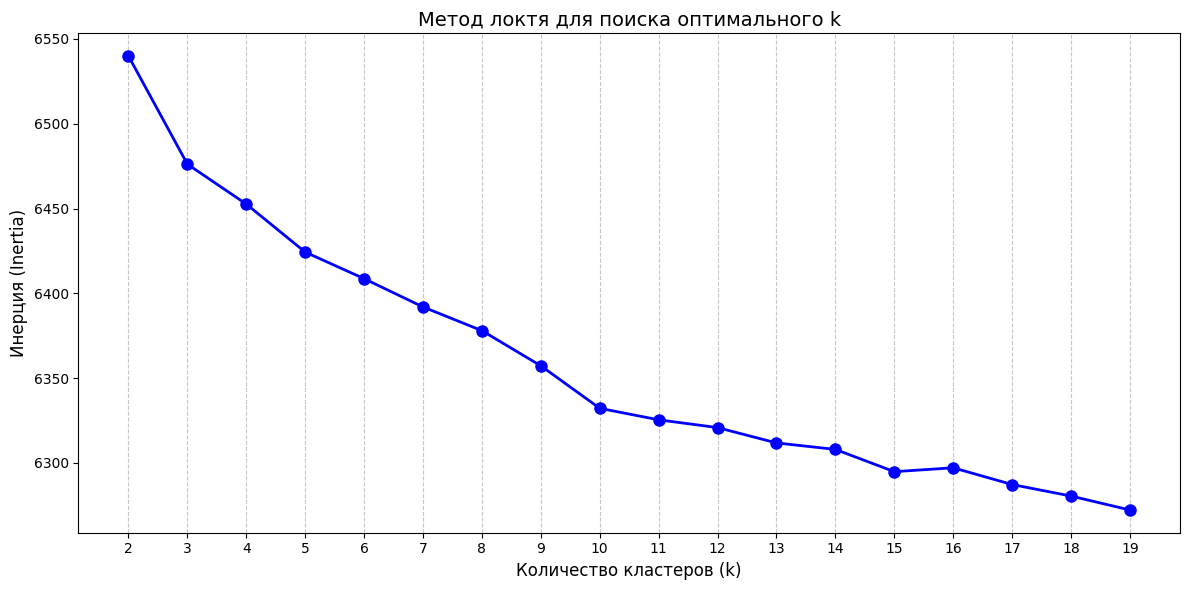

In [8]:
# используем метод локтя для определения оптимального количества кластеров

inertia = []
K = range(2, 20)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init='auto')
    kmeans.fit(embeddings)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(12, 6))
plt.plot(K, inertia, 'bo-', linewidth=2, markersize=8)

plt.xlabel('Количество кластеров (k)', fontsize=12)
plt.ylabel('Инерция (Inertia)', fontsize=12)
plt.title('Метод локтя для поиска оптимального k', fontsize=14)
plt.xticks(K) 
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [9]:
# получаем кластеры

if 'cluster' in df.columns:
    df = df.drop(columns=['cluster'])

kmeans = KMeans(n_clusters=8, random_state=RANDOM_STATE, n_init='auto')
cluster_labels = kmeans.fit_predict(embeddings)
post_text_df['cluster'] = cluster_labels
df = df.merge(
    post_text_df[['post_id', 'cluster']], 
    on='post_id', 
    how='left'
)
print(df['cluster'].value_counts())

cluster
5    1417208
2    1112327
4     917327
6     789388
1     564252
7     549636
0     389579
3     150838
Name: count, dtype: int64


In [10]:
# cортировка по времени
df = df.sort_values('timestamp').reset_index(drop=True)

# разделение на train/val по времени, тк нам нужно предсказывать будущее
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
val_df = df.iloc[split_idx:].copy()

print(f"Train size: {len(train_df)}, Val size: {len(val_df)}")

Train size: 4712444, Val size: 1178111


In [11]:
# новые фичи для пользователей

# 1. favorite_topic: самый частый топик среди просмотренных постов
user_topic_counts = train_df.groupby(['user_id', 'topic']).size().reset_index(name='count')
user_fav_topic = user_topic_counts.loc[user_topic_counts.groupby('user_id')['count'].idxmax()]
user_fav_topic = user_fav_topic.set_index('user_id')['topic'].to_dict()

# 2. loyalty = лайки / просмотры
user_loyalty = train_df.groupby('user_id')['target'].mean().to_dict()

# 3. likes_ratio = сумма лайков пользователя / сумма лайков просмотренных постов
post_likes = train_df[train_df['target']==1].groupby('post_id').size().to_dict()
train_df['post_likes'] = train_df['post_id'].map(post_likes).fillna(0)
user_sum_likes = train_df.groupby('user_id')['target'].sum()
user_sum_post_likes = train_df.groupby('user_id')['post_likes'].sum()
user_likes_ratio = (user_sum_likes / user_sum_post_likes).fillna(0).to_dict()

In [12]:
# новая фича для постов

# 4. likes to views ratio = количество лайков поста / количество просмотров поста
post_views = train_df.groupby('post_id').size()
post_likes_total = train_df[train_df['target']==1].groupby('post_id').size()
post_likes_to_views = (post_likes_total / post_views).fillna(0).to_dict()

In [13]:
# сохраняем средние значения для новых объектов, чтобы заполнить ими пропуски
# (например, когда пользователь ни разу ничего не лайкнул)

mean_loyalty = np.mean(list(user_loyalty.values()))
mean_likes_ratio = np.mean(list(user_likes_ratio.values()))
mean_likes_to_views = np.mean(list(post_likes_to_views.values()))
most_common_topic = train_df['topic'].mode()[0]

In [14]:
# применяем к train, val и исходному датасету
def enrich_features(df, user_fav_topic, user_loyalty, user_likes_ratio, post_likes_to_views,
                    mean_loyalty, mean_likes_ratio, mean_likes_to_views, most_common_topic):
    df = df.copy()
    # favorite_topic
    df['favorite_topic'] = df['user_id'].map(user_fav_topic).fillna(most_common_topic)
    # loyalty
    df['loyalty'] = df['user_id'].map(user_loyalty).fillna(mean_loyalty)
    # likes_ratio
    df['likes_ratio'] = df['user_id'].map(user_likes_ratio).fillna(mean_likes_ratio)
    # likes_to_views_ratio для поста
    df['likes_to_views_ratio'] = df['post_id'].map(post_likes_to_views).fillna(mean_likes_to_views)
    return df

train_df = enrich_features(train_df, user_fav_topic, user_loyalty, user_likes_ratio,
                            post_likes_to_views, mean_loyalty, mean_likes_ratio,
                            mean_likes_to_views, most_common_topic)

val_df = enrich_features(val_df, user_fav_topic, user_loyalty, user_likes_ratio,
                            post_likes_to_views, mean_loyalty, mean_likes_ratio,
                            mean_likes_to_views, most_common_topic)

df = enrich_features(df, user_fav_topic, user_loyalty, user_likes_ratio,
                            post_likes_to_views, mean_loyalty, mean_likes_ratio,
                            mean_likes_to_views, most_common_topic)

In [15]:
X_train = train_df.drop('target', axis=1)
y_train = train_df['target']

X_val = val_df.drop('target', axis=1)
y_val = val_df['target']

In [16]:
X_train.head()

,timestamp,user_id,post_id,action,gender,age,country,city,exp_group,os,source,text,topic,cluster,post_likes,favorite_topic,loyalty,likes_ratio,likes_to_views_ratio
0,2021-10-27 16:42:51,148233,1538,view,1,30,Russia,Saint Petersburg,1,Android,organic,Ferguson urges Henry punishment\n\nSir Alex Fe...,sport,6,220,sport,0.0,0.0,0.137672
1,2021-10-27 16:42:51,107427,6230,view,1,18,Russia,Samara,4,iOS,organic,"Well...there were some great, creamy-smooth fa...",movie,2,42,movie,0.0,0.0,0.094382
2,2021-10-27 16:42:51,155034,2195,view,0,15,Russia,Kazan,3,iOS,organic,Freeze on anti-spam campaign\n\nA campaign by ...,tech,0,50,tech,0.0,0.0,0.097656
3,2021-10-27 16:42:51,51391,5242,view,0,25,Russia,Achinsk,0,iOS,ads,"Now that I have seen it, it was NOT what I was...",movie,7,53,movie,0.0,0.0,0.107287
4,2021-10-27 16:42:51,65042,3860,view,1,56,Ukraine,Kyiv,0,Android,ads,"Thanks to @TPolasara, we got the necessary doc...",covid,5,179,covid,0.0,0.0,0.128777


In [17]:
def hitrate_at_k(eval_df, scores, user_liked_posts, k=5, target_col='target', user_col='user_id', post_col='post_id'):
    """
    hitrate@k: доля пользователей, для которых хотя бы один пост из топ-k
    по предсказанному скору (среди постов, которые юзер ещё не лайкал в train)
    оказался реально лайкнутым в валидационном периоде.
    """
    eval_df = eval_df.copy()
    eval_df['score'] = scores

    hits = 0
    total_users = 0

    for user_id, group in eval_df.groupby(user_col):
        already_liked = user_liked_posts.get(user_id, set())
        candidates = group[~group[post_col].isin(already_liked)]
        if candidates.empty:
            continue

        top_k = candidates.sort_values('score', ascending=False).head(k)
        total_users += 1
        if top_k[target_col].sum() > 0:
            hits += 1

    return hits / total_users if total_users > 0 else 0.0

In [19]:
# бейзлайн: ранжируем посты по популярности (likes_to_views_ratio, посчитан по train — см. ячейки 10-12)
# без учёта персонализации — чтобы понять, добавляет ли catboost ценность сверх простой популярности

# история лайков пользователей (только train) — не рекомендуем то, что уже лайкнуто
user_liked_posts = train_df[train_df['target'] == 1].groupby('user_id')['post_id'].apply(set).to_dict()

baseline_scores = val_df['likes_to_views_ratio'].values

baseline_auc = roc_auc_score(y_val, baseline_scores)
baseline_hr5 = hitrate_at_k(val_df, baseline_scores, user_liked_posts, k=5)

print(f"Baseline (популярность) — ROC-AUC: {baseline_auc:.4f}, HitRate@5: {baseline_hr5:.4f}")

Baseline (популярность) — ROC-AUC: 0.5427, HitRate@5: 0.5386


In [20]:
# признаки, влияющие наиболее сильно на результат по графику feature importance
# в результате предыдущих прогонов модели

top_names = ['topic', 'favorite_topic', 'loyalty', 'cluster', 'likes_ratio', 'likes_to_views_ratio', 'age']

In [21]:
X_train_top = X_train[top_names]
X_val_top = X_val[top_names]

In [22]:
X_val_top.head()

,topic,favorite_topic,loyalty,cluster,likes_ratio,likes_to_views_ratio,age
4712444,covid,movie,0.064516,5,0.000584,0.142857,22
4712445,movie,movie,0.100000,2,0.000564,0.106667,19
4712446,movie,movie,0.064516,2,0.000523,0.120316,38
4712447,movie,movie,0.100000,2,0.000613,0.083732,21
4712448,sport,movie,0.181818,6,0.002269,0.122707,35


In [ ]:
# # подбор гиперпараметров - закомментирован для скорости

# from catboost import CatBoostClassifier

# model = CatBoostClassifier(
#     iterations=50, 
#     border_count=32,
#     eval_metric='AUC:hints=skip_train~false',
#     random_seed=0,
#     class_weights=[1, 7],
#     cat_features=['topic', 'favorite_topic', 'cluster']
# )

# param_grid = {
#     'learning_rate': [0.01, 0.05, 0.1],
#     'depth': [4, 6, 8],
#     'l2_leaf_reg': [3, 5, 7]
# }

# grid_search_result = model.grid_search(
#     param_grid,
#     X=X_train_top,
#     y=y_train,
#     verbose=True,                
#     refit=True,               
#     partition_random_seed=0
# )

In [ ]:
# print(f"лучшие параметры: {grid_search_result['params']}")

In [23]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    learning_rate=0.1,
    depth=8,
    l2_leaf_reg=3,
    iterations=500,
    border_count=254,
    eval_metric='AUC:hints=skip_train~false',
    random_seed=RANDOM_STATE,
    class_weights=[1, 6],
    cat_features=['topic', 'favorite_topic', 'cluster'],
).fit(X_train_top, y_train)

from sklearn.metrics import classification_report

report = classification_report(y_val, model.predict(X_val_top), output_dict=True)
print(pd.DataFrame(report).T.round(3))

0:	learn: 0.6825329	total: 2.64s	remaining: 21m 57s
1:	learn: 0.6857514	total: 5.17s	remaining: 21m 28s
2:	learn: 0.6892400	total: 7.81s	remaining: 21m 33s
3:	learn: 0.6912801	total: 10.5s	remaining: 21m 47s
4:	learn: 0.6920776	total: 12.9s	remaining: 21m 20s
5:	learn: 0.6921989	total: 15.5s	remaining: 21m 17s
6:	learn: 0.6924021	total: 18.1s	remaining: 21m 11s
7:	learn: 0.6931395	total: 21s	remaining: 21m 29s
8:	learn: 0.6931874	total: 23.9s	remaining: 21m 43s
9:	learn: 0.6932300	total: 26.7s	remaining: 21m 46s
10:	learn: 0.6934020	total: 29.8s	remaining: 22m 2s
11:	learn: 0.6935363	total: 32.6s	remaining: 22m 7s
12:	learn: 0.6941929	total: 35.4s	remaining: 22m 4s
13:	learn: 0.6942846	total: 38.5s	remaining: 22m 16s
14:	learn: 0.6943122	total: 41.3s	remaining: 22m 15s
15:	learn: 0.6945842	total: 43.9s	remaining: 22m 8s
16:	learn: 0.6947244	total: 47s	remaining: 22m 15s
17:	learn: 0.6955579	total: 49.6s	remaining: 22m 8s
18:	learn: 0.6960765	total: 52.3s	remaining: 22m 5s
19:	learn: 0.

In [24]:
val_probs = model.predict_proba(X_val_top)[:, 1]

catboost_auc = roc_auc_score(y_val, val_probs)
catboost_hr5 = hitrate_at_k(val_df, val_probs, user_liked_posts, k=5)

print(f"CatBoost — ROC-AUC: {catboost_auc:.4f}, HitRate@5: {catboost_hr5:.4f}")
print(f"Прирост над бейзлайном — ROC-AUC: {catboost_auc - baseline_auc:+.4f}, HitRate@5: {catboost_hr5 - baseline_hr5:+.4f}")

# classification_report оставляем как дополнительную сводку по точности/полноте при пороге 0.5,
# но главная метрика качества ранжирования — выше
from sklearn.metrics import classification_report
report = classification_report(y_val, model.predict(X_val_top), output_dict=True)
print(pd.DataFrame(report).T.round(3))

CatBoost — ROC-AUC: 0.6136, HitRate@5: 0.6189
Прирост над бейзлайном — ROC-AUC: +0.0709, HitRate@5: +0.0804
              precision  recall  f1-score      support
0                 0.892   0.783     0.834  1032863.000
1                 0.174   0.323     0.226   145248.000
accuracy          0.727   0.727     0.727        0.727
macro avg         0.533   0.553     0.530  1178111.000
weighted avg      0.803   0.727     0.759  1178111.000


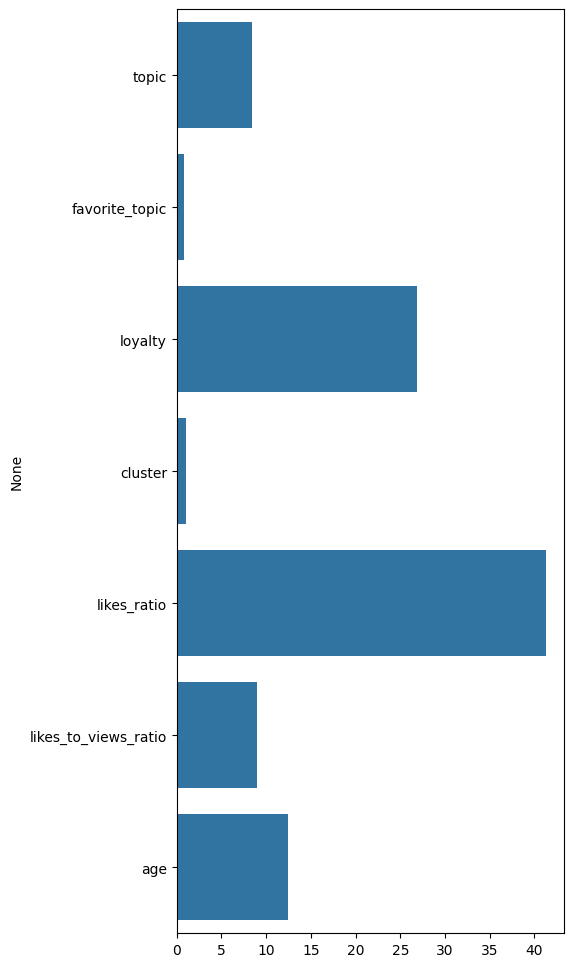

In [25]:
fig = plt.figure()
fig.set_size_inches(5,12)

sns.barplot(x=model.feature_importances_,
            y=X_train_top.columns)

plt.show()

In [26]:
# сохраняем модель, проверяем что она работает

model.save_model('model_control', format="cbm")

from_file = CatBoostClassifier() 

from_file.load_model("model_control")

print(from_file.predict(X_val_top))

[0 0 0 ... 0 0 0]


In [ ]:
# # загрузка информации о юзерах в БД

# user_cols = ['favorite_topic', 'loyalty', 'likes_ratio', 'age']
# user_cols.append('user_id')
# data_users = df.copy()[user_cols].drop_duplicates('user_id')

# engine = create_engine(
#     "postgresql://login:password@"
#     "postgres.lab.karpov.courses:6432/startml"
# )

# with engine.connect() as connection:
#     data_users.to_sql('nadezhda01em_users_control_1', con=connection)

In [ ]:
# # загрузка информации о постах в БД

# data_posts = post_text_df.merge(df[['likes_to_views_ratio', 'post_id']], 
#                                 on='post_id', how='left').drop_duplicates('post_id')

# engine = create_engine(
#     "postgresql://login:password@"
#     "postgres.lab.karpov.courses:6432/startml"
# )

# with engine.connect() as connection:
#     data_posts.to_sql('nadezhda01em_posts_control_1', con=connection)